# AGENTS026 – Hours 6–7: Reporting & Knowledge Base

This notebook closes the loop on the incident workflow. It creates a `PostIncidentReporterAgent` that generates a markdown incident report, appends finalized incidents into a simple knowledge base (KB), and updates the vector index so future RCA runs can retrieve newly resolved incidents.

At the end, you will be able to show:
- a final report for an incident,
- a growing KB table of resolved incidents,
- and refreshed retrieval over the expanded KB.


## Section 1 – Install / Import Dependencies

We continue with PydanticAI, FAISS, pandas, and sentence-transformers so we can both generate reports and update the retrieval layer.


In [1]:
%pip install -q pydantic-ai-slim openai pandas pyarrow faiss-cpu sentence-transformers

print('Installed / ensured pydantic-ai-slim, openai, pandas, pyarrow, faiss-cpu, sentence-transformers')


Note: you may need to restart the kernel to use updated packages.
Installed / ensured pydantic-ai-slim, openai, pandas, pyarrow, faiss-cpu, sentence-transformers


In [2]:
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Optional, Any
import os
import json
import asyncio

import pandas as pd
import numpy as np
import faiss
import torch
from pydantic import BaseModel, Field
from IPython.display import Markdown, display

from pydantic_ai import Agent, RunContext
from pydantic_ai.models.openai import OpenAIChatModel
from pydantic_ai.providers.openai import OpenAIProvider
from sentence_transformers import SentenceTransformer

print('Imports OK')


Imports OK


## Section 2 – Load Prior Workflow Outputs

Load incident candidates, RCA results, execution workflow bundles, and the current vector store.


In [3]:
root = Path.cwd() / 'agents026'
data_dir = root / 'data'
incidents_dir = data_dir / 'incidents'
exec_dir = data_dir / 'execution'
vector_dir = data_dir / 'vectorstore'
reports_dir = data_dir / 'reports'
kb_dir = data_dir / 'kb'
reports_dir.mkdir(parents=True, exist_ok=True)
kb_dir.mkdir(parents=True, exist_ok=True)

incident_candidates_path = incidents_dir / 'incident_candidates.json'
rca_results_path = incidents_dir / 'rca_results.json'
summary_path = exec_dir / 'workflow_summary.parquet'
index_path = vector_dir / 'incident_runbook.index'
meta_path = vector_dir / 'incident_runbook_metadata.parquet'

with open(incident_candidates_path, 'r', encoding='utf-8') as f:
    incident_candidates_raw = json.load(f)

with open(rca_results_path, 'r', encoding='utf-8') as f:
    rca_results_raw = json.load(f)

workflow_summary_df = pd.read_parquet(summary_path) if summary_path.exists() else pd.DataFrame()
corpus_df = pd.read_parquet(meta_path)
faiss_index = faiss.read_index(str(index_path))

workflow_files = sorted(exec_dir.glob('*_workflow.json'))
workflow_bundles = []
for fp in workflow_files:
    with open(fp, 'r', encoding='utf-8') as f:
        workflow_bundles.append(json.load(f))

len(workflow_bundles), faiss_index.ntotal


(2, 10)

## Section 3 – Recreate Schemas

Define the objects used by reporting and KB updates.


In [4]:
class IncidentCandidate(BaseModel):
    incident_id: str
    start_time: datetime
    end_time: datetime
    services: List[str]
    anomaly_type: str
    metric_summary: Dict[str, float] = Field(default_factory=dict)
    log_samples: List[str] = Field(default_factory=list)
    k8s_event_samples: List[str] = Field(default_factory=list)
    change_refs: List[str] = Field(default_factory=list)

class RCAResult(BaseModel):
    incident_id: str
    root_cause_hypothesis: str
    impacted_components: List[str]
    probable_trigger: Optional[str] = None
    evidence: List[str] = Field(default_factory=list)
    confidence: float = Field(..., ge=0.0, le=1.0)

class Action(BaseModel):
    action_id: str
    action_type: str
    target: str
    description: str
    parameters: Dict[str, object] = Field(default_factory=dict)
    requires_approval: bool = True
    status: str = 'pending'
    expected_impact: Optional[str] = None
    rationale: Optional[str] = None

class PostIncidentReport(BaseModel):
    incident_id: str
    markdown_report: str
    timeline: List[str] = Field(default_factory=list)
    actions_summary: List[str] = Field(default_factory=list)

incident_candidates = [IncidentCandidate(**x) for x in incident_candidates_raw]
incident_map = {x.incident_id: x for x in incident_candidates}
rca_results = [RCAResult(**x) for x in rca_results_raw]
rca_map = {x.incident_id: x for x in rca_results}

list(incident_map.keys())[:5]


['inc-001', 'inc-002', 'inc-003', 'inc-004']

## Section 4 – vLLM Client Setup

Use the same local vLLM endpoint used in previous notebooks.


In [5]:
BASE_URL = os.environ.get('BASE_URL', 'http://localhost:8000/v1')
OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY', 'abc-123')
MODEL_NAME = os.environ.get('MODEL_NAME', 'Qwen3-30B-A3B')

provider = OpenAIProvider(base_url=BASE_URL, api_key=OPENAI_API_KEY)
chat_model = OpenAIChatModel(MODEL_NAME, provider=provider)

print({'BASE_URL': BASE_URL, 'MODEL_NAME': MODEL_NAME})


{'BASE_URL': 'http://localhost:8000/v1', 'MODEL_NAME': 'Qwen3-30B-A3B'}


## Section 5 – PostIncidentReporterAgent

This agent creates a compact incident markdown report with:
- executive summary,
- timeline,
- actions taken,
- and learnings / follow-up.


In [10]:
class ReporterDeps(BaseModel):
    incident_map: Dict[str, IncidentCandidate]
    rca_map: Dict[str, RCAResult]
    workflow_bundles: Dict[str, Dict[str, object]]

workflow_map = {x['incident_id']: x for x in workflow_bundles}
reporter_deps = ReporterDeps(incident_map=incident_map, rca_map=rca_map, workflow_bundles=workflow_map)

REPORTER_SYSTEM_PROMPT = '''
You are a post-incident reporting agent for SRE teams.
Generate a concise markdown incident report suitable for demo and documentation use.
Requirements:
1. Include sections: Summary, Timeline, RCA, Actions Taken, Follow-up.
2. Be concrete and operational, not vague.
3. Use bullet points where appropriate.
4. Produce output as a PostIncidentReport structured object.
'''

reporter_agent = Agent(
    model=chat_model,
    deps_type=ReporterDeps,
    output_type=PostIncidentReport,
    system_prompt=REPORTER_SYSTEM_PROMPT,
)

@reporter_agent.tool
def get_incident(ctx: RunContext[ReporterDeps], incident_id: str) -> Dict[str, object]:
    return ctx.deps.incident_map[incident_id].model_dump()

@reporter_agent.tool
def get_rca(ctx: RunContext[ReporterDeps], incident_id: str) -> Dict[str, object]:
    return ctx.deps.rca_map[incident_id].model_dump()

@reporter_agent.tool
def get_workflow_bundle(ctx: RunContext[ReporterDeps], incident_id: str) -> Dict[str, object]:
    return ctx.deps.workflow_bundles[incident_id]

print('PostIncidentReporterAgent ready')


PostIncidentReporterAgent ready


In [11]:
class PostIncidentReporterAgentWrapper:
    def __init__(self, agent: Agent, deps: ReporterDeps):
        self.agent = agent
        self.deps = deps

    def build_prompt(self, incident_id: str) -> str:
        return (
            f'Generate a post-incident report for incident {incident_id}. '
            f'Use the incident details, RCA, and workflow bundle. Return PostIncidentReport.'
        )

    async def report_async(self, incident_id: str) -> PostIncidentReport:
        result = await self.agent.run(self.build_prompt(incident_id), deps=self.deps)
        return result.output

    def report(self, incident_id: str) -> PostIncidentReport:
        return asyncio.run(self.report_async(incident_id))

PostIncidentReporterAgent = PostIncidentReporterAgentWrapper(reporter_agent, reporter_deps)


## Section 6 – Generate 1–2 Reports

Run the reporter on one or two finalized incidents and save the markdown outputs.


In [8]:
report_incident_ids = [iid for iid in workflow_map.keys()][:2]
report_incident_ids


['inc-001', 'inc-002']

In [12]:
reports = []
for iid in report_incident_ids:
    try:
        report = await PostIncidentReporterAgent.report_async(iid)
        reports.append(report)
        md_path = reports_dir / f'{iid}_report.md'
        md_path.write_text(report.markdown_report, encoding='utf-8')
        print('Saved report to', md_path)
    except Exception as e:
        print('Failed for', iid, ':', repr(e))

len(reports)


Saved report to /workspace/agents026/data/reports/inc-001_report.md
Saved report to /workspace/agents026/data/reports/inc-002_report.md


2

## Section 7 – Show Final Markdown Report

Render the first generated report directly in the notebook.


In [13]:
if reports:
    display(Markdown(reports[0].markdown_report))
else:
    print('No reports generated yet')


## Post-Incident Report for Incident inc-001

### Summary
The incident involved a spike in error rates for the catalog-api service, which was traced back to recent deployments and feature flag changes. The root cause was identified as the deployment of version v2.1.8 and the activation of feature flag v2.2.2, which introduced inefficiencies in request handling. The actions taken included scaling down the service and clearing the cache, which helped mitigate the issue.

### Timeline
- **2026-06-10T12:13:00**: Feature flag (v2.2.2) applied to catalog-api.
- **2026-06-10T12:16:00**: Deployment (v2.1.8) applied to catalog-api.
- **2026-06-10T12:19:00**: Anomaly detected: error rate increased to 0.0032.
- **2026-06-10T12:20:00**: Action executed: scale_service (replicas=1) on catalog-api.
- **2026-06-10T12:24:00**: Action executed: clear_cache on catalog-api.

### Root Cause Analysis (RCA)
- **Root Cause Hypothesis**: The error rate increase is likely due to the recent deployment (v2.1.8) and feature flag activation (v2.2.2) around 12:13-12:16. These changes may have introduced inefficiencies or errors in request handling, leading to higher error rates.
- **Impacted Components**: catalog-api
- **Probable Trigger**: deploy
- **Evidence**: 
  - Similar incidents (inc-003, inc-002) involved deployment changes and feature flags.
  - Recent changes show a deploy at 12:16 and feature flag at 12:13.
  - Error rates spiked after these changes.
- **Confidence**: 95%

### Actions Taken
- **Scale Service**: Reduced replicas of catalog-api to 1 to mitigate load and error propagation.
- **Clear Cache**: Cleared the cache for catalog-api to remove corrupted or outdated data.

### Follow-up
- **Review Action Approval Process**: Investigate why disable_feature_flag and rollback_deploy actions were skipped due to approval requirements.
- **Monitor Service**: Continue monitoring catalog-api for any residual issues or recurrence of error rates.
- **Document Changes**: Ensure all deployments and feature flag changes are well-documented and reviewed before implementation to prevent similar incidents.


## Section 8 – Build / Update the Knowledge Base Table

We maintain a simple KB table where each resolved incident becomes a new reusable knowledge entry.
This can later be extended into a real postmortem/lessons-learned store.


In [14]:
kb_table_path = kb_dir / 'resolved_incidents_kb.parquet'

if kb_table_path.exists():
    kb_df = pd.read_parquet(kb_table_path)
else:
    kb_df = pd.DataFrame(columns=[
        'incident_id', 'services', 'anomaly_type', 'root_cause_hypothesis',
        'probable_trigger', 'confidence', 'actions_taken', 'report_markdown', 'kb_text'
    ])

new_rows = []
for report in reports:
    iid = report.incident_id
    if iid in set(kb_df['incident_id'].tolist()):
        continue
    incident = incident_map[iid]
    rca = rca_map[iid]
    wf = workflow_map[iid]
    executed = wf['execution_result']['executed_actions']
    actions_taken = [f"{a['action_type']}->{a['target']} ({a['status']})" for a in executed]
    kb_text = (
        f'incident_id={iid}; services={','.join(incident.services)}; anomaly_type={incident.anomaly_type}; '
        f'root_cause={rca.root_cause_hypothesis}; trigger={rca.probable_trigger}; '
        f'actions={'; '.join(actions_taken)}; '
        f'notes={report.markdown_report[:1500]}'
    )
    new_rows.append({
        'incident_id': iid,
        'services': ','.join(incident.services),
        'anomaly_type': incident.anomaly_type,
        'root_cause_hypothesis': rca.root_cause_hypothesis,
        'probable_trigger': rca.probable_trigger,
        'confidence': rca.confidence,
        'actions_taken': actions_taken,
        'report_markdown': report.markdown_report,
        'kb_text': kb_text,
    })

if new_rows:
    kb_df = pd.concat([kb_df, pd.DataFrame(new_rows)], ignore_index=True)

kb_df.to_parquet(kb_table_path, index=False)
print('KB rows:', len(kb_df))
kb_df[['incident_id', 'services', 'anomaly_type', 'root_cause_hypothesis', 'confidence']]


KB rows: 2


,incident_id,services,anomaly_type,root_cause_hypothesis,confidence
0,inc-001,catalog-api,error_rate,The error rate increase in catalog-api is like...,0.95
1,inc-002,catalog-api,error_rate,The error rate increase in catalog-api is like...,0.85


## Section 9 – Update Embeddings Index with Finalized Incidents

Now that we have resolved incidents and final reports, we embed them and append them to the FAISS index plus metadata table. This lets future RCA steps retrieve **resolved** incidents, not just synthetic history/runbooks.


In [15]:
embed_device = 'cuda' if torch.cuda.is_available() else 'cpu'
EMBED_MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
embed_model = SentenceTransformer(EMBED_MODEL_NAME, device=embed_device)

def embed_texts(texts: List[str], batch_size: int = 16) -> np.ndarray:
    vecs = embed_model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    return vecs.astype('float32')

print('Embedding model ready on', embed_device)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding model ready on cpu


In [16]:
existing_doc_ids = set(corpus_df['doc_id'].astype(str).tolist())
kb_docs = []
for row in kb_df.itertuples(index=False):
    doc_id = f'kb-{row.incident_id}'
    if doc_id in existing_doc_ids:
        continue
    kb_docs.append({
        'doc_id': doc_id,
        'doc_type': 'resolved_incident_kb',
        'service': row.services,
        'title': f'Resolved incident {row.incident_id}',
        'text': row.kb_text,
    })

if kb_docs:
    kb_docs_df = pd.DataFrame(kb_docs)
    kb_vectors = embed_texts(kb_docs_df['text'].tolist(), batch_size=16)
    faiss_index.add(kb_vectors)
    corpus_df = pd.concat([corpus_df, kb_docs_df], ignore_index=True)
    faiss.write_index(faiss_index, str(index_path))
    corpus_df.to_parquet(meta_path, index=False)
    print('Added KB docs to vector index:', len(kb_docs_df))
else:
    print('No new KB docs to add')

print('Updated FAISS size:', faiss_index.ntotal)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Added KB docs to vector index: 2
Updated FAISS size: 12


## Section 10 – Demonstrate KB Growth Over Time

Show how the KB table and vector corpus grow as incidents are resolved.


In [17]:
kb_growth_df = pd.DataFrame([
    {'stage': 'initial_vector_corpus', 'rows': len(pd.read_parquet(meta_path)) - len(kb_df)},
    {'stage': 'resolved_incident_kb_rows', 'rows': len(kb_df)},
    {'stage': 'final_vector_corpus', 'rows': len(pd.read_parquet(meta_path))},
])

kb_growth_df


,stage,rows
0,initial_vector_corpus,10
1,resolved_incident_kb_rows,2
2,final_vector_corpus,12


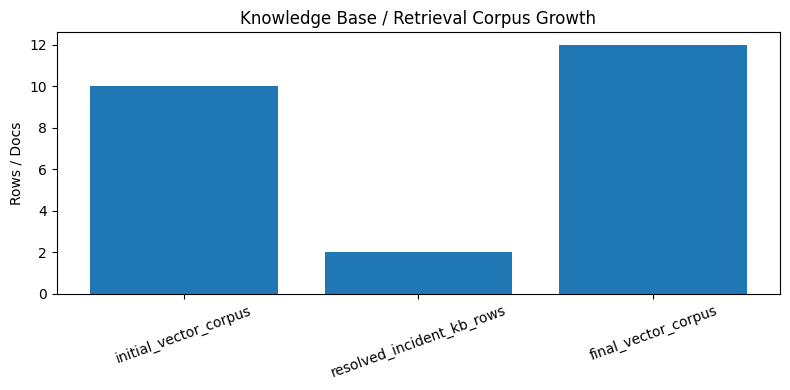

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(kb_growth_df['stage'], kb_growth_df['rows'])
plt.title('Knowledge Base / Retrieval Corpus Growth')
plt.ylabel('Rows / Docs')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## Section 11 – Retrieval Check Against Updated KB

Run a simple similarity search against the updated corpus to verify that newly added resolved incidents are searchable.


In [19]:
def search_similar_text(query_text: str, top_k: int = 5) -> pd.DataFrame:
    q = embed_texts([query_text], batch_size=1)
    scores, ids = faiss_index.search(q, top_k)
    rows = []
    for score, idx in zip(scores[0], ids[0]):
        if idx == -1:
            continue
        row = corpus_df.iloc[int(idx)].to_dict()
        row['score'] = float(score)
        rows.append(row)
    return pd.DataFrame(rows)

query = 'latency spike after deployment with rollback and restart actions'
search_similar_text(query, top_k=8)[['doc_id', 'doc_type', 'service', 'title', 'score']]


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

,doc_id,doc_type,service,title,score
0,rb-001,runbook,generic,Investigate latency regression after deploy,0.670707
1,hist-001,historical_incident,checkout-api,Checkout latency spike after deployment,0.521372
2,kb-inc-002,resolved_incident_kb,catalog-api,Resolved incident inc-002,0.425946
3,kb-inc-001,resolved_incident_kb,catalog-api,Resolved incident inc-001,0.391848
4,rb-003,runbook,generic,Rollback bad configuration change,0.370735
5,hist-003,historical_incident,auth-service,Auth failures after config change,0.340982
6,rb-002,runbook,generic,Database connection pool exhaustion remediation,0.291921
7,hist-002,historical_incident,payments-service,Payment error spike due to DB pool exhaustion,0.285618


## Section 12 – Persist Reporting Summary

Save a compact reporting summary for later demo or slide generation.


In [20]:
report_summary_rows = []
for report in reports:
    report_summary_rows.append({
        'incident_id': report.incident_id,
        'timeline_items': len(report.timeline),
        'actions_summary_items': len(report.actions_summary),
        'report_path': str(reports_dir / f'{report.incident_id}_report.md'),
    })

report_summary_df = pd.DataFrame(report_summary_rows)
report_summary_path = reports_dir / 'report_summary.parquet'
report_summary_df.to_parquet(report_summary_path, index=False)

print('Saved report summary to:', report_summary_path)
report_summary_df


Saved report summary to: /workspace/agents026/data/reports/report_summary.parquet


,incident_id,timeline_items,actions_summary_items,report_path
0,inc-001,5,2,/workspace/agents026/data/reports/inc-001_repo...
1,inc-002,4,4,/workspace/agents026/data/reports/inc-002_repo...
